# Accuracy Test Analysis
Reads `data/accuracy_test_results.csv` and plots a bar chart comparing mean Euclidean distance per test title,
colour-coded by calibration point count.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [18]:
CSV_PATH = "accuracy_test_results.csv"
df = pd.read_csv(CSV_PATH)
df.head(10)

,Title,cali_points,bg,point_index,target_x,target_y,cursor_x,cursor_y,distance
0,base,5,white,1,969,499,901.35,556.25,88.63
1,base,5,white,2,1560,930,1832.36,943.27,272.69
2,base,5,white,3,761,956,395.41,978.57,366.29
3,base,5,white,4,1078,722,1085.44,644.36,77.99
4,base,5,white,5,1775,511,1813.39,395.87,121.37
5,base,5,white,6,1165,107,1193.05,576.35,470.19
6,base,5,white,7,354,509,27.40,304.21,385.49
7,base,5,white,8,189,426,22.37,197.70,282.64
8,base,5,white,9,1014,570,973.58,557.64,42.26
9,base,5,white,10,531,227,161.49,163.10,374.99


In [19]:
# Mean distance per Title (keep cali_points for colouring)
summary = (
    df.groupby(["Title", "cali_points"])["distance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary.columns = ["Title", "cali_points", "Mean Distance (px)", "Std", "N"]
summary = summary.sort_values("Mean Distance (px)")
summary

,Title,cali_points,Mean Distance (px),Std,N
1,base,5,205.7770,123.098588,20
2,epsilon_0.05,5,209.6425,127.362191,20
0,45_frames,5,267.3240,110.492234,20


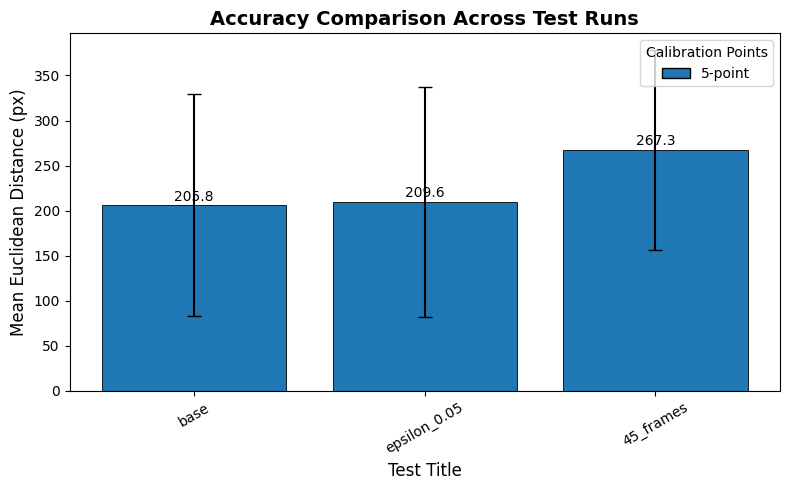

In [20]:
# --- Colour map: one colour per unique cali_points value ---
unique_pts = sorted(summary["cali_points"].unique())
cmap = plt.cm.tab10  # distinct categorical palette
pts_to_color = {pts: cmap(i / max(len(unique_pts) - 1, 1)) for i, pts in enumerate(unique_pts)}
bar_colors = [pts_to_color[p] for p in summary["cali_points"]]

fig, ax = plt.subplots(figsize=(max(8, len(summary) * 1.2), 5))

bars = ax.bar(
    summary["Title"], summary["Mean Distance (px)"],
    yerr=summary["Std"], capsize=5,
    color=bar_colors, edgecolor="black", linewidth=0.6,
)

ax.set_xlabel("Test Title", fontsize=12)
ax.set_ylabel("Mean Euclidean Distance (px)", fontsize=12)
ax.set_title("Accuracy Comparison Across Test Runs", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=30)

# Annotate bar values
for bar, val in zip(bars, summary["Mean Distance (px)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)

# Legend mapping colours to calibration point counts
legend_handles = [
    mpatches.Patch(facecolor=pts_to_color[p], edgecolor="black", label=f"{p}-point")
    for p in unique_pts
]
ax.legend(handles=legend_handles, title="Calibration Points", loc="upper right")

plt.tight_layout()
plt.show()